## Volcano Plot from Loupe Cluster Data by Andrew Levy

Reusable notebook for visualizing differential expression for a given cluster from a Loupe Browser
differential expression CSV (using log2 fold change and p-value values from genes in a single cluster compared to all other clusters in the sample).

How to use:

## 1. Fetching Data from Loupe Browser.
To start this process, we must fetch data from the 10x Genomics Loupe Database.

Go here and work through the getting started section: https://www.10xgenomics.com/support/software/loupe-browser/latest/getting-started (here read about the Loupe Browser and then go back and Click "Download & Install")

Install the application by launching the installer.

Scroll through this tutorial to familiarize yourself with the interface. You do not need to download this dataset, just use the tutorial to understand what is possible. https://www.10xgenomics.com/support/software/loupe-browser/latest/tutorials/introduction/lb-sc-interface-and- navigation

Go back to the home site of the Loupe browser application, click on Public datasets.

Pick a dataset, click on Explore data, then click on Download files and open in Loupe Browser.

Once in a Loupe browser, click on "Differential Expression Output." Under this tab, download the data using the button the thr right of the setting gear at the top right of the table of data.

Once the data is downloaded, note the file path for Step 5 where you will input it to retrieve the data.

# Step 5 is very important and really the only part the user must interact with:
In step 5 you must:
1. Set `CSV_PATH` at your exported CSV.
2. Set `CLUSTER_NUMBER` to the cluster you want to plot.
3. Tweak thresholds and annotation count if needed.

Run all cells top-to-bottom.


## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 3. Volcano plot function

This code is essentially an instruction manual and result that takes pre-computed log2 fold changes and p-values (as found in a Loupe export) and renders a volcano plot. Unlike our original lab 7 version, this does not calculate statistics from raw expression data from a complex expression datset.

Index for next chunk in which we are creating the volcano plot function:    

log2_fc : array-like Log2 fold change for each gene.
        
   p_values : array-like P-value for each gene.
        
gene_names : array-like, Gene labels for annotation step.
        
title : Plot title.
        
log2_fc_threshold :|log2FC| cutoff for calling a gene significant.
        
p_threshold : P-value cutoff for significance.
        
figsize : Figure size (width, height).
        
up_color, down_color : Colors for significantly up- / down-regulated points.
        
#### annotate_top_n :  Number of top significant genes to label (ranked by |log2FC| * -log10(p)).

fig, ax : matplotlib Figure and Axes

In [2]:
# Creating a volcano plot is somewhat simple in Python, There is just a lot of extra functions I added to make the program more userfriendly and replicable.
def create_volcano_plot(log2_fc, p_values, gene_names=None,
                        title="Volcano Plot",
                        log2_fc_threshold=1, p_threshold=0.05,
                        figsize=(10, 8),
                        up_color="crimson", down_color="steelblue",
                        annotate_top_n=20):
   
    #This command section converts inputs from the data set to "code-able" numpy arrays. Essential for getting CSV to be used.
    log2_fc = np.asarray(log2_fc, dtype=float)
    p_values = np.asarray(p_values, dtype=float)
    if gene_names is not None:
        gene_names = np.asarray(gene_names)

    # Block below gets rid of genes that have a missing log2FC or p-value.
    # AI GENERATED, next 5 lines
    valid = ~(np.isnan(log2_fc) | np.isnan(p_values)) #this line checks the data set for non-real numbers
    log2_fc = log2_fc[valid] 
    p_values = p_values[valid]
    if gene_names is not None:
        gene_names = gene_names[valid]

    # Floors any zero p-values so -log10 stays finite
    # Another potential issue with the Loupe files is that sometimes very significant p-values are reported at 0 which messes up the y-axis as log10
    # of 0 is nevative infinity.
    # So the fix: find the smallest positive p-value actually in the data, divide it by 10 (or another number but not too important), and use that as a floor. 
    # This is okay because as we learned significant values cannot be "more significant" than another, they are all equal once significant.
    # The highly significant values listed as 0 will still be the smallest as they are the next smallest p-value but divided.
    # AI GENERATED, next 4 lines
    positive = p_values[p_values > 0]
    floor = (positive.min() / 10) if positive.size else 1e-300 #These two lines find the smallest value in the data, divide it by 10 and set it as the "floor"
    p_values = np.where(p_values <= 0, floor, p_values) #"wherever p ≤ 0, replace with floor; otherwise keep the original."

    neg_log_p = -np.log10(p_values)

    # The function below categroizes the points based on if they are above and below each threshold.
    sig = p_values < p_threshold
    up = sig & (log2_fc > log2_fc_threshold)
    down = sig & (log2_fc < -log2_fc_threshold)
    ns = ~(up | down)
    
#Function below creates the points and the legend shown in top left of plot.
    fig, ax = plt.subplots(figsize=figsize) #creates canvas essentially, each ax.scatter creates points based on grouping of ns, up, down.
    ax.scatter(log2_fc[ns], neg_log_p[ns],
               alpha=0.4, color="lightgray", s=18,
               label=f"Not significant (n={ns.sum()})")
    ax.scatter(log2_fc[up], neg_log_p[up],
               alpha=0.85, color=up_color, s=26,
               label=f"Up in cluster (n={up.sum()})")
    ax.scatter(log2_fc[down], neg_log_p[down],
               alpha=0.85, color=down_color, s=26,
               label=f"Down in cluster (n={down.sum()})")

    # This then creates the visualization threshold lines after they are set above
    ax.axhline(-np.log10(p_threshold), color="black", linestyle="--", alpha=0.3)
    ax.axvline(log2_fc_threshold, color="black", linestyle="--", alpha=0.3)
    ax.axvline(-log2_fc_threshold, color="black", linestyle="--", alpha=0.3)

    #Now creating labels and titles, again this is all stylistic parts of the volcano plot
    ax.set_xlabel("Log2 Fold Change", fontsize=12)
    ax.set_ylabel("-Log10 P-value", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    # This is now creating point labels for top-N significant genes, there is later a function that allows the user to choose how many points they want labeled
    if annotate_top_n and gene_names is not None:
        sig_mask = up | down
        if sig_mask.any():
            score = neg_log_p * np.abs(log2_fc)
            score_masked = np.where(sig_mask, score, -np.inf)
            top_idx = np.argsort(score_masked)[-annotate_top_n:]
            for i in top_idx:
                if sig_mask[i]:
                    ax.annotate(str(gene_names[i]),
                                (log2_fc[i], neg_log_p[i]),
                                xytext=(5, 5),
                                textcoords="offset points",
                                fontsize=8)

    plt.tight_layout() #this is a nice little function that tells matplotlib to make sure everything is shown and not cutoff, adjusts all the spacing.
    return fig, ax 


## 4. Making it more user-friendly to load a file and cluster from a Loupe CSV
The chunk below makes loading clusters more streamlined, first part allows user to easily type which lister they want to look at. Second part ensures that clusters that don't exist in the file can't be typed.

A Loupe  export has columns named like
`Cluster 7 Log2 Fold Change` and `Cluster 7 P-Value`. This next chunk is again not completely necassary but pulls the
three columns we need for one cluster regardless of column name. It prevents the user from having to type out the columns they want each time they upload a new file. I was personally getting annoyed at having to type the file and clister columns each time

If a file uses a different gene-label column than the default which is `FeatureName`, and you try to use df["FeatureName"] — but this file doesn't have a FeatureName column, it, for example, has a "Gene" column. The missing-column check would trigger and raise an error telling the user FeatureName isn't there.

To make it work on that file, the user tells the function to use "Gene" instead of the default "FeatureName". You do that by including gene_name_col="Gene" when you call it in the first line.

In [3]:
def load_loupe_cluster(csv_path, cluster_number,
                       gene_name_col="FeatureName"):
    
    #Loads a Loupe differential expression CSV and return pre-computed (log2_fc, p_values, gene_names) for a single cluster.
    
    df = pd.read_csv(csv_path) #now that everything is set, this reads the data that is input
    fc_col = f"Cluster {cluster_number} Log2 Fold Change" #This line and next build the column names. Replaces "f" with deisred cluter number
    p_col = f"Cluster {cluster_number} P-Value" 
    missing = [c for c in (fc_col, p_col, gene_name_col) if c not in df.columns] #This a recomended improvement by AI in which the code will now tell the user if a column doesn't exist instead of breaking the plot.
    if missing:
        raise ValueError(
            f"Missing columns {missing}. "
            f"Available: {list(df.columns)}" # Essentially saying if column does not exist in dataset, it will say so. Again, more user-friendly addition. 
        )
    return (df[fc_col].values,
            df[p_col].values,
            df[gene_name_col].values)


# 5. Plotting Clusters
## The first 5 lines of this chunk are the most important to visualize desired plots. 
## Change `CSV_PATH` / `CLUSTER_NUMBER` to look at any other Loupe export and cluster. 
## Change thresholds based on desired results. They are already set to what makes sense generally speaking.
## Change ANNOTATE_TOP_N for how many labeled points are desired.

* If you want, you can copy and paste the next chunk into a new one over and over, changing CSV paths and clusters to compare different clusters/files side by side.

Loaded 1150 genes for cluster 7


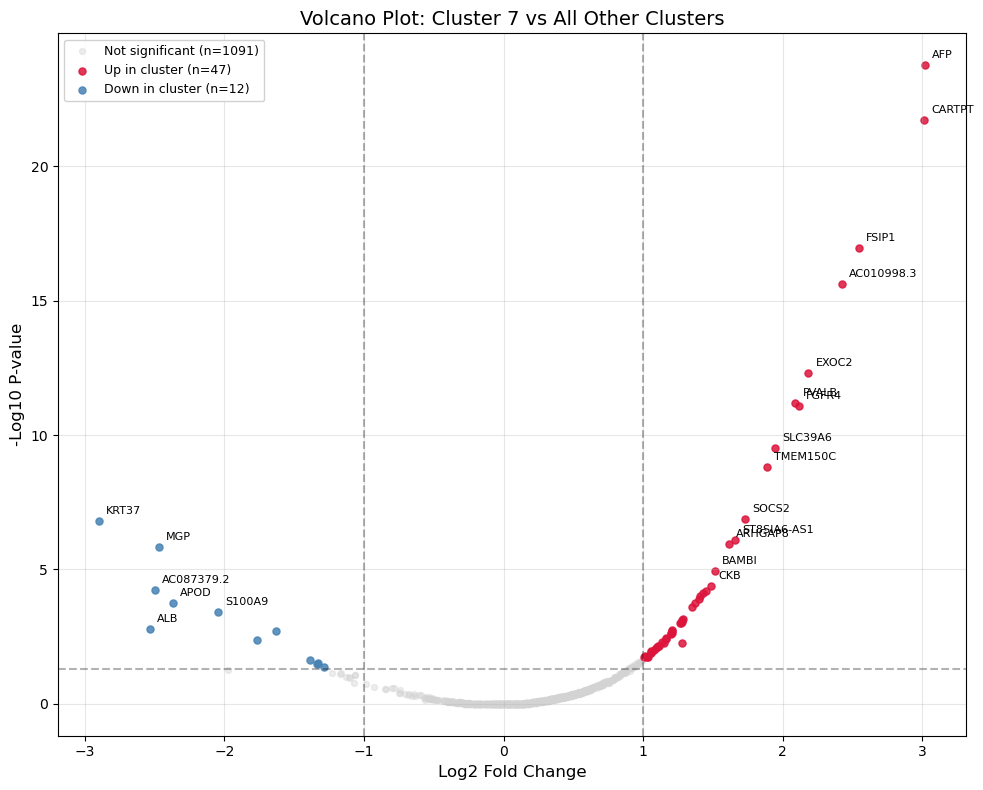

In [4]:
# Plotting data here now that we have plot and data defined
CSV_PATH = "/Users/andrewlevy/Desktop/2026 Spring Bio373 CompBio/humanBC.csv"          # path to your Loupe differential expression CSV
CLUSTER_NUMBER = 7 # which cluster column to plot
LOG2FC_THRESHOLD = 1              # |log2 fold change| cutoff
P_THRESHOLD = 0.05                # p-value cutoff
ANNOTATE_TOP_N = 20               # how many top genes to label

log2_fc, p_values, gene_names = load_loupe_cluster(CSV_PATH, CLUSTER_NUMBER) #This loads the data from the input file path and cluster
print(f"Loaded {len(log2_fc)} genes for cluster {CLUSTER_NUMBER}")

#Below is handing the data to the volcano plot function where it actually makes the plot.
fig, ax = create_volcano_plot(
    log2_fc, p_values, gene_names,
    title=f"Volcano Plot: Cluster {CLUSTER_NUMBER} vs All Other Clusters",
    log2_fc_threshold=LOG2FC_THRESHOLD,
    p_threshold=P_THRESHOLD,
    annotate_top_n=ANNOTATE_TOP_N,
)
plt.show()


Paste step 5 code here and change file path and/or cluster to compare! :)